In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from worldcup.tournament import load_teams, get_groups, get_group_matches
from worldcup.simulator import GroupStageSimulator
from worldcup.algorithms.poisson import PoissonGoalModel, _poisson_pmf
from worldcup.algorithms.nathan_rating import NathanRatingModel

sns.set_theme(style='whitegrid', palette='muted')

# ── Configure model here ──────────────────────────────────────────────────────
rating_model = NathanRatingModel(fifa_power=1.0, w_fifa=0.5, w_equality=0.5)
predictor = PoissonGoalModel(rating_model, base_lambda=1.3, alpha=0.3, max_ratio=10.0)
N_SIMULATIONS = 20_000
SEED = 42
# ─────────────────────────────────────────────────────────────────────────────

teams = load_teams()
groups = get_groups(teams)
flag_map  = {t.name: t.flag  for t in teams}
group_map = {t.name: t.group for t in teams}

# Nathan model

## Algorithm

Nathan combines two rankings into a single team strength score:

1. **FIFA Elo points** — the continuous point scores underlying the official FIFA ranking (higher = stronger). Using points rather than rank position means the near-identical gap between rank 1 and rank 2 is correctly reflected as tiny, rather than being treated as a 2× difference.
2. **LGBT Equality Index** ([Equaldex](https://www.equaldex.com/equality-index), 0–100) — **inverted**: a lower equality score contributes a *higher* rating.

The model tests the hypothesis: *do countries with worse LGBT equality perform better at football?*

### Rating formula

$$\text{rating} = w_f \cdot \frac{\text{points}}{\text{points}_{\max}} + w_e \cdot \frac{100 - \text{equality}}{100}$$

| Parameter | Value | Role |
|---|---|---|
| $w_f$ | 0.5 | Weight on FIFA Elo points component |
| $w_e$ | 0.5 | Weight on inverted equality component |

The rating feeds into the Poisson goal model:
$$\lambda_h = \lambda_0 \cdot \text{ratio}^{\alpha}, \qquad \lambda_a = \frac{\lambda_0}{\text{ratio}^{\alpha}}$$
with $\lambda_0 = 1.3$, $\alpha = 0.3$, max ratio cap = 10.

### Component breakdown — all WC teams

In [2]:
rows = []
for t in sorted(teams, key=lambda t: rating_model.rate(t), reverse=True):
    rank, pts, equality = rating_model._rankings[t.name]
    fifa_score = pts / rating_model._max_points
    eq_score   = (100.0 - equality) / 100.0
    rows.append({
        'Team':          f'{flag_map[t.name]} {t.name}',
        'FIFA rank':     rank,
        'FIFA points':   round(pts, 2),
        'Equality':      int(equality),
        'FIFA score':    round(fifa_score, 4),
        'Inv. equality': round(eq_score, 4),
        'Nathan rating': round(rating_model.rate(t), 4),
    })

breakdown = pd.DataFrame(rows)
breakdown.style \
    .hide(axis='index') \
    .background_gradient(subset='Nathan rating', cmap='RdYlGn', vmin=0, vmax=1) \
    .background_gradient(subset='FIFA points',   cmap='RdYlGn', vmin=700, vmax=1900) \
    .background_gradient(subset='Equality',      cmap='RdYlGn', vmin=0, vmax=100)

Team,FIFA rank,FIFA points,Equality,FIFA score,Inv. equality,Nathan rating
🇸🇳 Senegal,15,1684.070000,4,0.897600,0.960000,0.928800
🇮🇷 Iran,20,1619.580000,5,0.863300,0.950000,0.906600
🇲🇦 Morocco,7,1755.100000,13,0.935500,0.870000,0.902700
🇪🇬 Egypt,29,1562.370000,10,0.832800,0.900000,0.866400
🇩🇿 Algeria,28,1571.030000,13,0.837400,0.870000,0.853700
🇶🇦 Qatar,57,1450.310000,8,0.773000,0.920000,0.846500
🇹🇳 Tunisia,45,1476.410000,14,0.786900,0.860000,0.823500
🇮🇶 Iraq,56,1451.150000,13,0.773500,0.870000,0.821700
🇸🇦 Saudi Arabia,61,1423.880000,13,0.758900,0.870000,0.814500
🇨🇮 Ivory Coast,33,1540.870000,23,0.821300,0.770000,0.795700


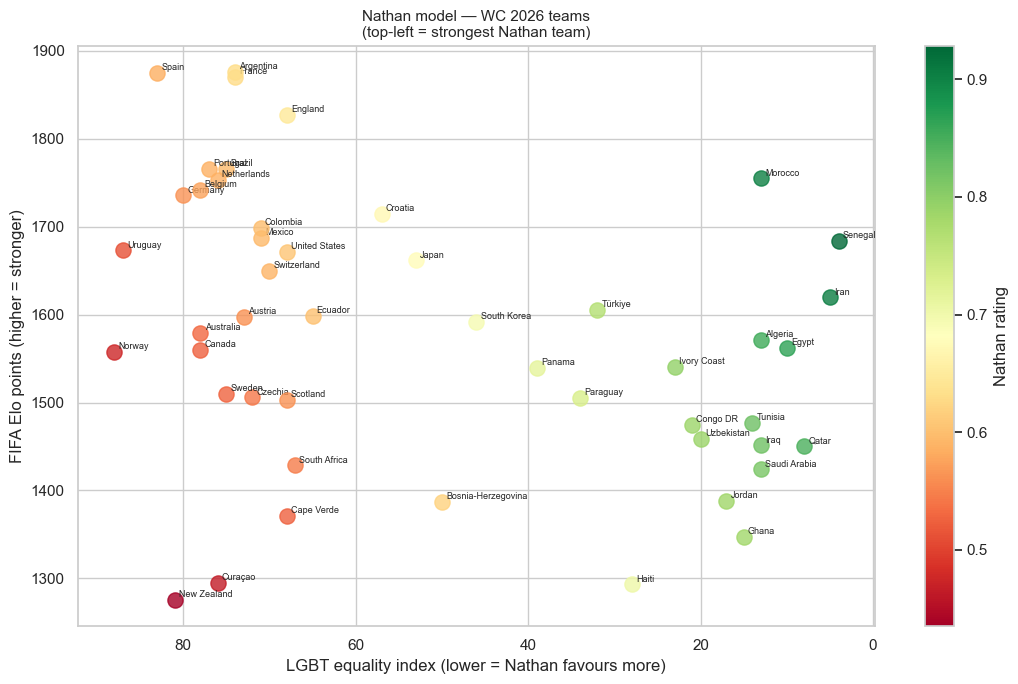

In [3]:
# Scatter: equality score vs FIFA points, colour = Nathan rating
fig, ax = plt.subplots(figsize=(11, 7))

nathan_scores = [rating_model.rate(t) for t in teams]
norm = plt.Normalize(min(nathan_scores), max(nathan_scores))
cmap = plt.cm.RdYlGn

for t in teams:
    _, pts, equality = rating_model._rankings[t.name]
    nathan = rating_model.rate(t)
    ax.scatter(equality, pts, s=120, alpha=0.8, color=cmap(norm(nathan)), zorder=3)
    ax.annotate(t.name, (equality, pts), fontsize=6.5,
                xytext=(3, 2), textcoords='offset points')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Nathan rating')

ax.set_xlabel('LGBT equality index (lower = Nathan favours more)')
ax.set_ylabel('FIFA Elo points (higher = stronger)')
ax.set_title('Nathan model — WC 2026 teams\n(top-left = strongest Nathan team)', fontsize=11)
ax.invert_xaxis()
plt.tight_layout()
plt.show()

### Example prediction — Spain vs Iran

Spain: 1874.71 pts, equality 83 → Nathan 0.5846
Iran:  1619.58 pts, equality 5 → Nathan 0.9066
λ_home = 1.140,  λ_away = 1.483


Outcome,Probability
🇪🇸 Spain win,29.1%
Draw,25.8%
🇮🇷 Iran win,45.1%


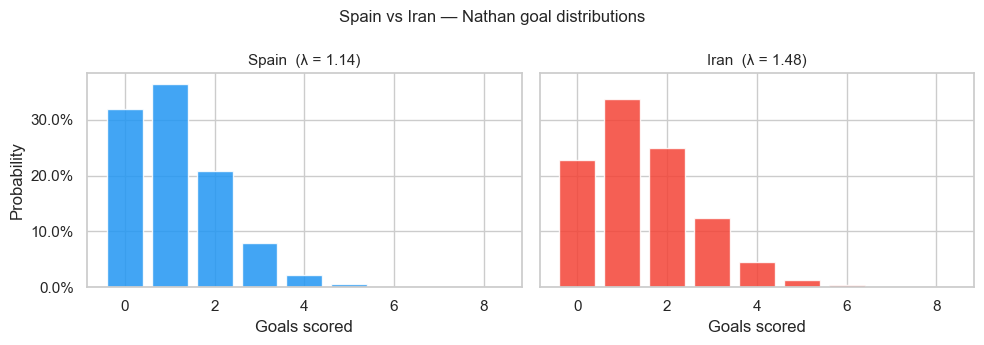

In [4]:
example_home = next(t for t in teams if t.name == 'Spain')
example_away = next(t for t in teams if t.name == 'Iran')

_, pts_h, eq_h = rating_model._rankings[example_home.name]
_, pts_a, eq_a = rating_model._rankings[example_away.name]
λ_h, λ_a = predictor.lambdas(example_home, example_away)
p_home, p_draw, p_away = predictor.predict(example_home, example_away)

print(f'{example_home.name}: {pts_h:.2f} pts, equality {eq_h:.0f} → Nathan {rating_model.rate(example_home):.4f}')
print(f'{example_away.name}:  {pts_a:.2f} pts, equality {eq_a:.0f} → Nathan {rating_model.rate(example_away):.4f}')
print(f'λ_home = {λ_h:.3f},  λ_away = {λ_a:.3f}')

example_df = pd.DataFrame([
    {'Outcome': f'{example_home.flag} {example_home.name} win', 'Probability': p_home},
    {'Outcome': 'Draw',                                          'Probability': p_draw},
    {'Outcome': f'{example_away.flag} {example_away.name} win', 'Probability': p_away},
])
display(example_df.style.hide(axis='index')
        .format({'Probability': '{:.1%}'})
        .bar(subset='Probability', color='#90CAF9', vmin=0, vmax=1))

max_g = 8
goals = np.arange(0, max_g + 1)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5), sharey=True)
axes[0].bar(goals, [_poisson_pmf(g, λ_h) for g in goals], color='#2196F3', alpha=0.85)
axes[0].set_title(f'{example_home.name}  (λ = {λ_h:.2f})', fontsize=11)
axes[0].set_xlabel('Goals scored'); axes[0].set_ylabel('Probability')
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
axes[1].bar(goals, [_poisson_pmf(g, λ_a) for g in goals], color='#F44336', alpha=0.85)
axes[1].set_title(f'{example_away.name}  (λ = {λ_a:.2f})', fontsize=11)
axes[1].set_xlabel('Goals scored')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
fig.suptitle(f'{example_home.name} vs {example_away.name} — Nathan goal distributions', fontsize=12)
plt.tight_layout(); plt.show()

---

## Group stage qualification probabilities

In [5]:
sim = GroupStageSimulator(predictor, n=N_SIMULATIONS, seed=SEED)
results = sim.run(groups)
df = results.to_dataframe()

df['flag']     = df['team'].map(flag_map)
df['group']    = df['team'].map(group_map)
df['Team']     = df['flag'] + ' ' + df['team']
df['equality'] = df['team'].map(lambda n: int(rating_model._rankings[n][2]))
df['points']   = df['team'].map(lambda n: round(rating_model._rankings[n][1], 1))

qual_table = df[['group', 'Team', 'points', 'equality', 'p_qualify', 'p_group_winner', 'p_runner_up', 'p_best_third', 'p_eliminated']].copy()
qual_table.columns = ['Group', 'Team', 'FIFA pts', 'Equality', 'Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']

qual_table.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Qualify', '1st', '2nd', 'Best 3rd', 'Eliminated']}) \
    .background_gradient(subset='Qualify',    cmap='RdYlGn',   vmin=0, vmax=1) \
    .background_gradient(subset='Eliminated', cmap='RdYlGn_r', vmin=0, vmax=1) \
    .background_gradient(subset='Equality',   cmap='RdYlGn',   vmin=0, vmax=100) \
    .background_gradient(subset='FIFA pts',   cmap='RdYlGn',   vmin=1200, vmax=1900)

Group,Team,FIFA pts,Equality,Qualify,1st,2nd,Best 3rd,Eliminated
G,🇮🇷 Iran,1619.600000,5,77.9%,33.9%,28.2%,15.7%,22.1%
H,🇸🇦 Saudi Arabia,1423.900000,13,77.6%,35.8%,26.6%,15.2%,22.4%
B,🇶🇦 Qatar,1450.300000,8,77.1%,34.7%,27.3%,15.1%,22.9%
E,🇨🇮 Ivory Coast,1540.900000,23,76.9%,34.5%,26.7%,15.7%,23.1%
I,🇸🇳 Senegal,1684.100000,4,76.9%,34.4%,27.1%,15.4%,23.1%
C,🇲🇦 Morocco,1755.100000,13,76.8%,34.7%,27.0%,15.1%,23.2%
G,🇪🇬 Egypt,1562.400000,10,76.2%,32.8%,27.4%,16.0%,23.8%
F,🇹🇳 Tunisia,1476.400000,14,75.2%,32.6%,26.5%,16.1%,24.8%
J,🇩🇿 Algeria,1571.000000,13,74.3%,31.9%,26.3%,16.1%,25.7%
I,🇮🇶 Iraq,1451.200000,13,73.5%,29.7%,28.0%,15.8%,26.5%


---

## Match predictions

In [6]:
match_rows = []
for group_name, group_teams in sorted(groups.items()):
    for home, away in get_group_matches(group_teams):
        λ_h, λ_a = predictor.lambdas(home, away)
        p_hw, p_d, p_aw = predictor.predict(home, away)
        match_rows.append({
            'Group':      group_name,
            'Home':       f'{home.flag} {home.name}',
            'Away':       f'{away.flag} {away.name}',
            'λ home':     round(λ_h, 3),
            'λ away':     round(λ_a, 3),
            'Home win %': p_hw,
            'Draw %':     p_d,
            'Away win %': p_aw,
        })

matches_df = pd.DataFrame(match_rows)
matches_df.style \
    .hide(axis='index') \
    .format({c: '{:.1%}' for c in ['Home win %', 'Draw %', 'Away win %']}) \
    .background_gradient(subset='Home win %', cmap='Blues',  vmin=0, vmax=1) \
    .background_gradient(subset='Away win %', cmap='Reds',   vmin=0, vmax=1) \
    .background_gradient(subset='Draw %',     cmap='Greens', vmin=0, vmax=1)

Group,Home,Away,λ home,λ away,Home win %,Draw %,Away win %
A,🇲🇽 Mexico,🇿🇦 South Africa,1.334000,1.267000,38.4%,26.4%,35.2%
A,🇲🇽 Mexico,🇰🇷 South Korea,1.241000,1.362000,34.0%,26.3%,39.7%
A,🇲🇽 Mexico,🇨🇿 Czechia,1.337000,1.264000,38.5%,26.4%,35.1%
A,🇿🇦 South Africa,🇰🇷 South Korea,1.209000,1.397000,32.5%,26.2%,41.3%
A,🇿🇦 South Africa,🇨🇿 Czechia,1.303000,1.297000,37.0%,26.4%,36.7%
A,🇰🇷 South Korea,🇨🇿 Czechia,1.401000,1.207000,41.4%,26.2%,32.4%
B,🇨🇦 Canada,🇧🇦 Bosnia-Herzegovina,1.237000,1.366000,33.8%,26.3%,39.9%
B,🇨🇦 Canada,🇶🇦 Qatar,1.127000,1.500000,28.5%,25.7%,45.8%
B,🇨🇦 Canada,🇨🇭 Switzerland,1.256000,1.346000,34.7%,26.4%,38.9%
B,🇧🇦 Bosnia-Herzegovina,🇶🇦 Qatar,1.184000,1.428000,31.3%,26.1%,42.6%
